# Experiments Analysis & Hypothesis Notebook

This notebook serves as the central collaboration space for hypothesis testing and experiment analysis.

## How to Use This Notebook

1. **Manifest (auto-generated)**: `experiments/experiments_manifest.csv` is automatically updated when evaluations run
2. **Hypotheses (human-defined)**: Define hypotheses below with linked experiments
3. **Analysis (collaborative)**: Both human and AI can add observations and analysis

## Workflow
1. Run evaluations: `python notebooks/eval_fun.py` → updates manifest
2. Load manifest below to see all evaluated experiments
3. Define or update hypotheses with experiment IDs
4. Analyze results collaboratively

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join, exists
import json

# Load manifest utilities
from causaliT.evaluation.eval_funs.update_manifest import load_experiments_manifest
#from eval_fun import load_experiments_manifest, update_experiments_manifest, MANIFEST_PATH

# Plotting settings
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

---
# 1. Experiments Manifest

Auto-generated table of all evaluated experiments.

In [2]:
# Load the experiments manifest
manifest = load_experiments_manifest()

if len(manifest) > 0:
    # Display summary
    print(f"Total experiments: {len(manifest)}")
    print(f"Datasets: {manifest['dataset'].unique().tolist()}")
    print(f"Architectures: {manifest['architecture'].unique().tolist()}")
    print()
    
    # Show table
    # display(manifest[[
    #     "exp_id", "dataset", "architecture", "attention", "cross_attention", 
    #     "best_val_loss", "best_test_r2", "last_evaluated"]])
    
    display(manifest)
else:
    print("No experiments in manifest yet. Run evaluations to populate.")

Total experiments: 106
Datasets: ['scm6', 'scm7', 'scm1_linear_gaussian', 'scm2_nonlinear_gaussian', 'scm3_nonlinear_nongaussian']
Architectures: ['SingleCausalLayer', 'NoiseAwareSingleCausalLayer']



,exp_id,path,dataset,architecture,attention,cross_attention,max_epochs,learning_rate,batch_size,optimizer,...,val_loss_spike_ratio_mean,val_loss_spike_ratio_std,val_loss_cv_mean,val_loss_cv_std,val_loss_max_jump_mean,val_loss_max_jump_std,val_loss_trend_instability_mean,val_loss_trend_instability_std,last_evaluated,available_evals
0,ANS_single_Lie_SM_scm6_SVFA_59792944,experiments/single/scm6/euler\ANS_single_Lie_S...,scm6,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-13T17:01:13,"[""eval_ans"", ""eval_attention_scores"", ""eval_do..."
1,ANS_single_Lie_SM_scm6_SVFA_59908753,experiments/single/scm6/euler\ANS_single_Lie_S...,scm6,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-03-13T17:01:13,"[""eval_ans"", ""eval_attention_scores"", ""eval_do..."
2,single_Lie_SM_scm6_59251043,experiments/single/scm6/euler\single_Lie_SM_sc...,scm6,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.470,0.036878,0.626712,0.571630,0.000094,0.000054,0.000023,0.000015,2026-03-13T17:01:13,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
3,single_Lie_SM_scm6_antisym_59251000,experiments/single/scm6/euler\single_Lie_SM_sc...,scm6,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.484,0.032000,8.088368,3.547661,0.003821,0.000920,2.051327,2.323293,2026-03-13T17:01:13,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
4,single_Lie_SM_scm6_gated_59250941,experiments/single/scm6/euler\single_Lie_SM_sc...,scm6,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.432,0.033705,8.283059,3.147444,0.003423,0.000402,0.893426,0.849582,2026-03-13T17:01:13,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,single_SM_SM_scm3_60473080,experiments\single\scm3\euler\single_SM_SM_scm...,scm3_nonlinear_nongaussian,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.454,0.028000,1.403553,0.158507,0.000142,0.000030,0.000205,0.000048,2026-03-16T15:45:30,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
102,na_single_Toeplitz_CC_scm1_60473011,experiments\noise_aware_single\scm1\euler\na_s...,scm1_linear_gaussian,NoiseAwareSingleCausalLayer,ToeplitzLieAttention,CausalCrossAttention,100,0.001,64,adamw,...,0.456,0.014967,-0.023840,0.003564,0.089597,0.029323,0.015236,0.003362,2026-03-16T16:28:15,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
103,na_single_Toeplitz_CC_scm1_60474978,experiments\noise_aware_single\scm1\euler\na_s...,scm1_linear_gaussian,NoiseAwareSingleCausalLayer,ToeplitzLieAttention,CausalCrossAttention,100,0.001,64,adamw,...,0.448,0.032496,-0.025661,0.005604,0.087078,0.027323,0.014911,0.002561,2026-03-16T16:28:38,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
104,na_single_Toeplitz_CC_scm2_60473032,experiments\noise_aware_single\scm2\euler\na_s...,scm2_nonlinear_gaussian,NoiseAwareSingleCausalLayer,ToeplitzLieAttention,CausalCrossAttention,100,0.001,64,adamw,...,0.430,0.037417,-0.063182,0.012674,0.065165,0.007475,0.019262,0.001661,2026-03-16T16:28:58,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."


---
# 2. Hypotheses

Define scientific hypotheses and link them to experiments by `exp_id`.

## H1: Intervention Invariance is guaranteed when the true DAG is provided ✅

**Question:** Does the transformer prevent non-causal mixing if the actual causal DAG is provided in the attention blocks?

**Expected Outcomes:**
- Variations in non-parents do not change children's distribution. For scm6: interventions in S1 do not change X2 and its descendent's distributions.

**Experiments:**
- `single_SM_SM_scm6_59250773` (baseline, no mask)
- `single_SM_SM_scm6_hard_59250752` true DAG mask provided

**Status:** <span style="color: green;">Evaluated</span>

##### **Findings:** Providing the true DAG ensures intervention-invariance. 

In [3]:
# H1: Intervention Invariance is guaranteed when the true DAG is provided
H1_experiments = [
    "single_SM_SM_scm6_59250773",
    "single_SM_SM_scm6_hard_59250752"
]

# Filter manifest for H1 experiments
if len(manifest) > 0:
    h1_data = manifest[manifest["exp_id"].isin(H1_experiments)]
    if len(h1_data) > 0:
        display(h1_data)
    else:
        print("No H1 experiments found in manifest yet.")

,exp_id,path,dataset,architecture,attention,cross_attention,max_epochs,learning_rate,batch_size,optimizer,...,val_loss_spike_ratio_mean,val_loss_spike_ratio_std,val_loss_cv_mean,val_loss_cv_std,val_loss_max_jump_mean,val_loss_max_jump_std,val_loss_trend_instability_mean,val_loss_trend_instability_std,last_evaluated,available_evals
11,single_SM_SM_scm6_59250773,experiments/single/scm6/euler\single_SM_SM_scm...,scm6,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.462,0.013266,0.954369,0.640274,0.000133,0.000057,0.000032,0.000018,2026-03-13T17:01:14,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
12,single_SM_SM_scm6_hard_59250752,experiments/single/scm6/euler\single_SM_SM_scm...,scm6,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.460,0.026833,0.238250,0.179790,0.000073,0.000039,0.000013,0.000004,2026-03-13T17:01:14,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."


### H1 Observations

<!-- Human observations -->
**Francesco (date):**
- Looking at the `eval/eval_do/default/files/do_summary_csv` one can see that $P(S_2|X_1=k)=P(S_2)$ for the hard-mask and $P(S_2|X_1=k)\neq P(S_2)$ if the hard-mask is not provided. 

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H2: Residual - Parents independence higher if true DAG is provided, compared to when the wrong one is provided instead. ⌛

**Question:** Consider the Hilber-Schmidt Independence Criterion (HSIC) between residuals and sources, do we measure lower HSIC when we provide the true DAG compared to a wrong one?

**Expected Outcomes:**
- HSIC lower when the true DAG is provided

**Experiments:**

- `single_SM_SM_scm6_59250773` (baseline, no mask)
- `single_SM_SM_scm6_hard_59250752` true DAG mask provided

**Status:** <span style="color: red;"> **REDO**</span> (With the wrong mask. without mask you don't see the difference)

##### **Findings:** 

In [4]:
# H2: Residual - Parents independence higher if true DAG is provided, compared to when the wrong one is provided instead.
H2_experiments = [
    "single_SM_SM_scm6_59250773",
    "single_SM_SM_scm6_hard_59250752"
]

# Filter manifest for H2 experiments
if len(manifest) > 0:
    h2_data = manifest[manifest["exp_id"].isin(H2_experiments)]
    if len(h2_data) > 0:
        display(h2_data)
    else:
        print("No H2 experiments found in manifest yet.")

,exp_id,path,dataset,architecture,attention,cross_attention,max_epochs,learning_rate,batch_size,optimizer,...,val_loss_spike_ratio_mean,val_loss_spike_ratio_std,val_loss_cv_mean,val_loss_cv_std,val_loss_max_jump_mean,val_loss_max_jump_std,val_loss_trend_instability_mean,val_loss_trend_instability_std,last_evaluated,available_evals
11,single_SM_SM_scm6_59250773,experiments/single/scm6/euler\single_SM_SM_scm...,scm6,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.462,0.013266,0.954369,0.640274,0.000133,0.000057,0.000032,0.000018,2026-03-13T17:01:14,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
12,single_SM_SM_scm6_hard_59250752,experiments/single/scm6/euler\single_SM_SM_scm...,scm6,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.460,0.026833,0.238250,0.179790,0.000073,0.000039,0.000013,0.000004,2026-03-13T17:01:14,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."


### H2 Observations

<!-- Human observations -->
**Francesco (date):**
- Overall, H2 seems to hold
- The HSIC seems also depending on the quality of the fit: even when the true DAG is provided, if the model has insufficient capacity to fit the data, it results in a high HSIC.
- H2 validation suggests that HSIC could be potentially used as a regularization term to improve causal discovery. 

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H3: Lie attention improves causal discovery ✅

**Question:** Does Lie attention improve the transformer capability in distinguishing between correlation and causality?

**Expected Outcomes:**
- Hamming distance lower in models with Lie attention ✅

<span style="color: red;"> **REDO**</span> (seed bug in trainer)

##### **Findings:** Verified for scm6 and scm7

In [5]:
# H3: Lie attention improves causal discovery
H3_experiments = [
    "single_SM_SM_scm6_59250773",   # baseline scm6
    "single_Lie_SM_scm6_59251043",  # Lie scm6
    "single_SM_SM_scm7_59971110",   # baseline scm7
    "single_Lie_SM_scm7_59970904"   # Lie scm7
]

# Filter manifest for H2 experiments
if len(manifest) > 0:
    h3_data = manifest[manifest["exp_id"].isin(H3_experiments)][["exp_id",
        "test_loss_mean", "soft_hamming_self_mean", "soft_hamming_self_best", "soft_hamming_self_worst"]]
    if len(h3_data) > 0:
        display(h3_data)
    else:
        print("No H3 experiments found in manifest yet.")

,exp_id,test_loss_mean,soft_hamming_self_mean,soft_hamming_self_best,soft_hamming_self_worst
2,single_Lie_SM_scm6_59251043,0.000107,0.249016,0.180316,0.352066
11,single_SM_SM_scm6_59250773,0.000107,0.365744,0.259391,0.480670
20,single_Lie_SM_scm7_59970904,0.000044,0.253446,0.180317,0.352066
29,single_SM_SM_scm7_59971110,0.000035,0.505453,0.297983,0.739020


### H3 Observations

<!-- Human observations -->
**Francesco (14/03/2026):** 
- In the scm6-7 datasets, Lie attention scored a lower SHD. It is therefore better than standard softmax. 
 

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H4: Freezing sequential stage parameters improves causal discovery

**Question:**

**Expected Outcomes:**

**Experiments:**

**Status:** Not started

## H5: Reducing the batch size improves causal discovery

**Question:**

**Expected Outcomes:**

**Experiments:**

**Status:** Not started

## H6: Embedding separation improves causal discovery

**Question:**

**Expected Outcomes:**

**Experiments:**

**Status:** Not started

## H7: Learning stage noise improves causal discovery ❌

**Question:** By introducing a learnable noise at each stage, can the stage output be better explained by inter-stage interactions (self-attention) than short-cutting to stage parents (cross-attention)?

*Example:* In scm6, X1 could learn X2 from its parents S2 and S3 and completely ignore the causal relation X2->X1. But, if we equip X2 with a stochastic noise (learnable), X1 could prefer X2 from its deterministic parents, as this noise could better explain the targets. 

**Expected Outcomes:**
- better causal metrics for noise-aware architectures.

<span style="color: red;"> **REDO**</span> (seed bug in trainer)

##### **Findings:** not always useful

In [6]:
# H7: Intervention Invariance is guaranteed when the true DAG is provided
H7_experiments = [
    # "single_SM_SM_scm1_60473063",   # baseline scm1
    # "single_SM_SM_scm2_60473079",   # baseline scm2
    # "single_SM_SM_scm3_60473080",   # baseline scm3
    
    # # Toeplitz - SoftMax
    # "na_single_Toeplitz_SM_scm1_60422213", 
    # "na_single_Toeplitz_SM_scm2_60422247",
    # "na_single_Toeplitz_SM_scm3_60422284",
    
    "single_Lie_SM_scm6_59251043",      # baseline scm6
    "na_single_Lie_SM_scm6_59728613",   # Lie noise-aware scm6
    "single_Lie_SM_scm7_59970904",      # baseline scm7
    "na_single_Lie_SM_scm7_59903106",   # Lie noise-aware scm7
    
]

# Filter manifest for H7 experiments
if len(manifest) > 0:
    h7_data = manifest[manifest["exp_id"].isin(H7_experiments)]
    if len(h7_data) > 0:
        h7_data = h7_data[["exp_id", "dataset", "soft_hamming_cross_mean","soft_hamming_self_mean", "dag_confidence_cross"]]
    else:
        print("No H7 experiments found in manifest yet.")
        
display(h7_data)

,exp_id,dataset,soft_hamming_cross_mean,soft_hamming_self_mean,dag_confidence_cross
2,single_Lie_SM_scm6_59251043,scm6,0.462441,0.249016,0.909614
20,single_Lie_SM_scm7_59970904,scm7,0.515676,0.253446,0.836118
94,na_single_Lie_SM_scm6_59728613,scm6,0.394854,0.297886,0.943339
95,na_single_Lie_SM_scm7_59903106,scm7,0.581142,0.297886,0.541283


## H8: DAGs from non-Linear SCM are easier to learn from linear ones ❌

**Question:** Linear Gaussian SCM are not identifiable because it is always possible to find a "backward" model (with additive noise assumption) that is able to describe the observational data. Non-linearity in the structural equations and non-Gaussian noise are known to be desired property for causal discovery. Do the models identify better causal relations in a non-linear setting? 

**Expected Outcomes:**
- consistently lower (better) SHD for non-linear dataset


<span style="color: red;"> **REDO**</span> (seed bug in trainer)

##### **Findings:** Non-linearity does NOT make things always easier. 

In [7]:
H8_experiments = [
    
    "single_Lie_SM_scm6_59251043",
    "single_Lie_SM_scm7_59970904",
    
    "single_SM_SM_scm6_59250773",
    "single_SM_SM_scm7_59971110",
    
    "single_Toeplitz_SM_scm6_59250713",
    "single_Toeplitz_SM_scm7_59969899",
    
    "na_single_Lie_SM_scm6_59728613",
    "na_single_Lie_SM_scm7_59903106"
]

# Filter manifest for H8 experiments
group = ["architecture", "attention"]
control = ["dataset"]
metrics = ["test_loss_mean", "soft_hamming_cross_mean", "soft_hamming_self_mean"]
if len(manifest) > 0:
    h8_data = manifest[manifest["exp_id"].isin(H8_experiments)][group + control + metrics]
    if len(h8_data) > 0:
        display(h8_data)
    else:
        print("No H8 experiments found in manifest yet.")
        
grouped = h8_data.groupby(group + control).first().unstack("dataset")
result = pd.DataFrame(index=grouped.index)

# Compute percent increase for all metrics at once (vectorized)
for metric in metrics:
    result[f"{metric}_percent_increase"] = (
        (grouped[metric]["scm7"] - grouped[metric]["scm6"]) / grouped[metric]["scm6"] * 100
    )

result.reset_index(inplace=True)
display(result)

,architecture,attention,dataset,test_loss_mean,soft_hamming_cross_mean,soft_hamming_self_mean
2,SingleCausalLayer,LieAttention,scm6,0.000107,0.462441,0.249016
11,SingleCausalLayer,ScaledDotProduct,scm6,0.000107,0.467858,0.365744
13,SingleCausalLayer,ToeplitzLieAttention,scm6,0.000111,0.459801,0.166309
20,SingleCausalLayer,LieAttention,scm7,0.000044,0.515676,0.253446
29,SingleCausalLayer,ScaledDotProduct,scm7,0.000035,0.557946,0.505453
30,SingleCausalLayer,ToeplitzLieAttention,scm7,0.000138,0.531768,0.235297
94,NoiseAwareSingleCausalLayer,LieAttention,scm6,-4.110930,0.394854,0.297886
95,NoiseAwareSingleCausalLayer,LieAttention,scm7,-4.690992,0.581142,0.297886


,architecture,attention,test_loss_mean_percent_increase,soft_hamming_cross_mean_percent_increase,soft_hamming_self_mean_percent_increase
0,NoiseAwareSingleCausalLayer,LieAttention,14.110231,47.179082,0.000000
1,SingleCausalLayer,LieAttention,-58.655674,11.511821,1.779056
2,SingleCausalLayer,ScaledDotProduct,-67.763881,19.255330,38.198458
3,SingleCausalLayer,ToeplitzLieAttention,24.894160,15.651756,41.482262


### H8 Observations

<!-- Human observations -->
**Francesco (date):**
- Noise Aware: all causal discovery metrics are worse in the non-linear setting. The reason is still unclear. Is the dataset "too" non-linear?
- In all considered models, SHD is higher (worse) in scm7 than for scm6.

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H9: The HSIC regularizer helps the transformer to converge to the true DAG representation ✅ 

**Question:**

**Expected Outcomes:**
- better DAG metrics with higher regularization

**Status:** <span style="color: green;"> **DONE**</span>

##### **Findings**: In most cases, the HSIC regularizer helps but consider using annealing to avoid the negative effects.

,exp_id,path,dataset,architecture,attention,cross_attention,max_epochs,learning_rate,batch_size,optimizer,...,val_loss_spike_ratio_mean,val_loss_spike_ratio_std,val_loss_cv_mean,val_loss_cv_std,val_loss_max_jump_mean,val_loss_max_jump_std,val_loss_trend_instability_mean,val_loss_trend_instability_std,last_evaluated,available_evals
54,sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_s...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.432,0.030594,0.698600,0.163211,0.000491,0.000103,0.000086,0.000013,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
55,sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_s...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,PhiSoftMax,ScaledDotProduct,100,0.001,64,adamw,...,0.444,0.030725,0.855705,0.111788,0.000349,0.000053,0.000067,0.000018,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
56,sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_s...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.444,0.030725,0.855705,0.111788,0.000349,0.000053,0.000067,0.000018,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
57,sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_s...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,ToeplitzLieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.442,0.017205,0.637136,0.167718,0.000603,0.000194,0.000091,0.000014,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
58,sweep_hsic_scm7_combo_lambda_hsic_1000000.0_de...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.470,0.029665,0.053264,0.007772,0.140567,0.022465,0.019345,0.002440,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
59,sweep_hsic_scm7_combo_lambda_hsic_1000000.0_de...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,PhiSoftMax,ScaledDotProduct,100,0.001,64,adamw,...,0.468,0.016000,0.048874,0.008942,0.121068,0.036503,0.018443,0.003671,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
60,sweep_hsic_scm7_combo_lambda_hsic_1000000.0_de...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,ScaledDotProduct,ScaledDotProduct,100,0.001,64,adamw,...,0.468,0.016000,0.048874,0.008942,0.121068,0.036503,0.018443,0.003671,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
61,sweep_hsic_scm7_combo_lambda_hsic_1000000.0_de...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,ToeplitzLieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.482,0.019391,0.083313,0.056584,0.120703,0.024238,0.020527,0.005275,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
62,sweep_hsic_scm7_combo_lambda_hsic_1000000000.0...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,LieAttention,ScaledDotProduct,100,0.001,64,adamw,...,0.466,0.032000,0.053401,0.009278,141.952332,31.501175,19.266949,2.758484,2026-03-13T17:11:25,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."
63,sweep_hsic_scm7_combo_lambda_hsic_1000000000.0...,experiments\single\scm7\euler\sweep_hsic_scm7_...,scm7,SingleCausalLayer,PhiSoftMax,ScaledDotProduct,100,0.001,64,adamw,...,0.476,0.017436,0.048665,0.008792,120.961591,36.731455,18.304545,3.608500,2026-03-13T17:11:26,"[""eval_attention_scores"", ""eval_do"", ""eval_emb..."


Text(0.5, 1.0, 'val_loss_max_jump_mean scm7')

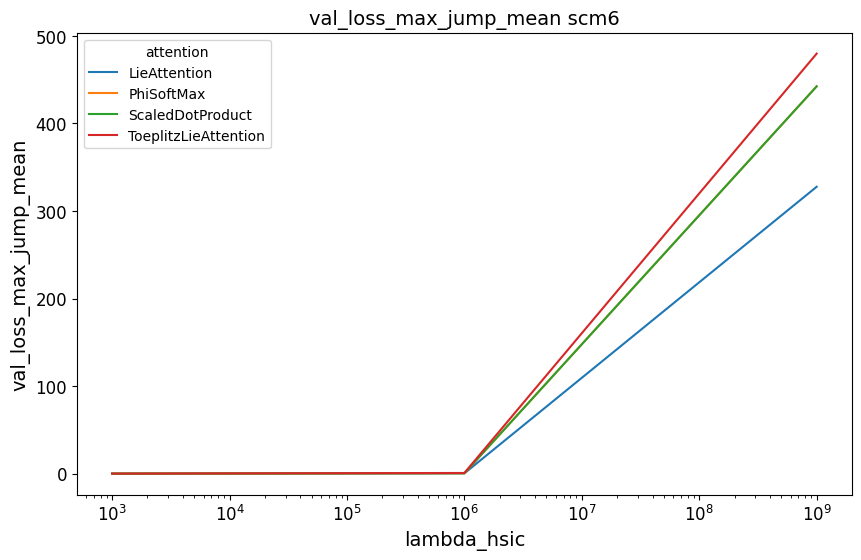

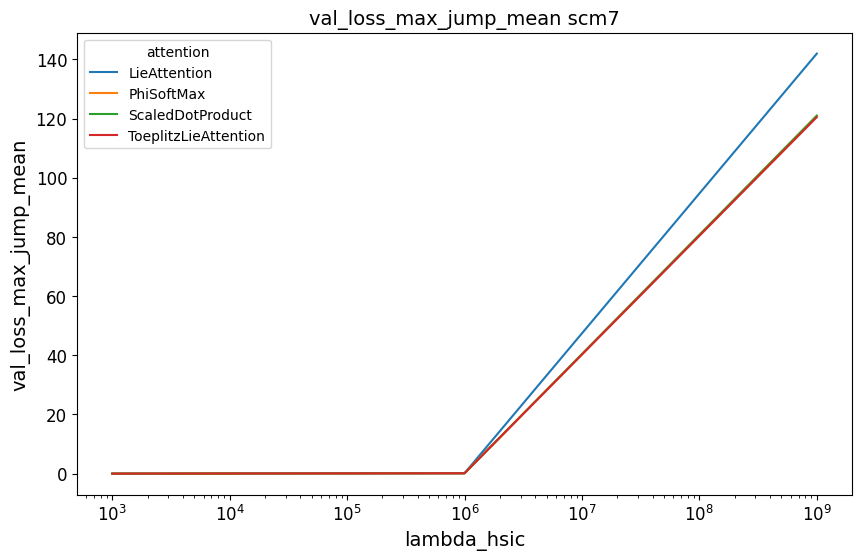

In [8]:
# H9: Intervention Invariance is guaranteed when the true DAG is provided
H9_experiments = [
    # scm6
    "sweep_hsic_scm6_combo_lambda_hsic_1000.0_dec_self_attention_type_LieAttention",
    "sweep_hsic_scm6_combo_lambda_hsic_1000.0_dec_self_attention_type_PhiSoftMax",
    "sweep_hsic_scm6_combo_lambda_hsic_1000.0_dec_self_attention_type_ScaledDotProduct",
    "sweep_hsic_scm6_combo_lambda_hsic_1000.0_dec_self_attention_type_ToeplitzLieAttention",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000.0_dec_self_attention_type_LieAttention",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000.0_dec_self_attention_type_PhiSoftMax",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000.0_dec_self_attention_type_ScaledDotProduct",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000.0_dec_self_attention_type_ToeplitzLieAttention",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000000.0_dec_self_attention_type_LieAttention",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000000.0_dec_self_attention_type_PhiSoftMax",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000000.0_dec_self_attention_type_ScaledDotProduct",
    "sweep_hsic_scm6_combo_lambda_hsic_1000000000.0_dec_self_attention_type_ToeplitzLieAttention",
    
    # scm7
    "sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_self_attention_type_LieAttention",
    "sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_self_attention_type_PhiSoftMax",
    "sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_self_attention_type_ScaledDotProduct",
    "sweep_hsic_scm7_combo_lambda_hsic_1000.0_dec_self_attention_type_ToeplitzLieAttention",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000.0_dec_self_attention_type_LieAttention",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000.0_dec_self_attention_type_PhiSoftMax",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000.0_dec_self_attention_type_ScaledDotProduct",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000.0_dec_self_attention_type_ToeplitzLieAttention",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000000.0_dec_self_attention_type_LieAttention",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000000.0_dec_self_attention_type_PhiSoftMax",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000000.0_dec_self_attention_type_ScaledDotProduct",
    "sweep_hsic_scm7_combo_lambda_hsic_1000000000.0_dec_self_attention_type_ToeplitzLieAttention"
]

# Filter manifest for H9 experiments
if len(manifest) > 0:
    h9_data = manifest[manifest["exp_id"].isin(H9_experiments)]
    if len(h9_data) > 0:
        display(h9_data)
    else:
        print("No H9 experiments found in manifest yet.")

import seaborn as sns
import matplotlib.pyplot as plt

# fit quality metrics "test_loss_mean"
# training stability ["val_loss_max_jump_mean", "val_loss_trend_instability_mean"]
# interesting metrics [dag_confidence_self/cross, soft_hamming_self/cross_mean/best/worst]

metric = "val_loss_max_jump_mean" 

fig, ax1 = plt.subplots()
sns.lineplot(data=h9_data[h9_data["dataset"]=="scm6"], x="lambda_hsic", y=metric, hue="attention", ax=ax1)
ax1.set_xscale("log")
ax1.set_title(metric + " scm6")

fig2, ax2 = plt.subplots()
sns.lineplot(data=h9_data[h9_data["dataset"]=="scm7"], x="lambda_hsic", y=metric, hue="attention", ax=ax2)
ax2.set_xscale("log")
ax2.set_title(metric + " scm7")

### H9 Observations

<!-- Human observations -->
**Francesco (14/03/2026):**
- Toeplitz: `lambda_HSIC` improved the self and cross worst SHD and, therefore, the confidence in scm6
- All: `lambda_HSIC` improved the cross worst SHD and therefore confidence, in both scm6 and scm7
- All: the best SHD is either not affected or gets slightly worse with higher `lambda_HSIC`
- It looks like this regularization particularly helps in avoiding very bad DAG configurations, but annealing might be useful to reduce this effect as training proceed and avoid instabilities: for very high `lambda_HSIC`, the test loss is very high.

<!-- AI observations -->
**Cline (date):**

## H10: The KL regularizer helps the transformer to converge to the true DAG representation. 

**Question:**

**Expected Outcomes:**

**Experiments:**

**Status:** <span style="color: orange;"> **RUNNING**</span>

## H11: Structure–Value Factorized Attention (SVFA) improves DAG learning consistency ❔

**Question:** By decoupling structural alignment (Q·K^T depends on variable IDs) from value aggregation (V depends on realizations), does SVFA improve DAG learning consistency across k-fold cross-validation?

**Mechanism:** In standard attention, Q and K are projected from fused embeddings (variable ID + value), causing attention patterns to vary with fold-specific value correlations. SVFA restricts Q·K^T to depend only on variable embeddings, eliminating this source of fold-specific variation.

**Expected Outcomes:**
- Primary: Higher `dag_confidence_cross` and `dag_confidence_self` compared to standard factorization
- Secondary: Lower or equal `soft_hamming_*_mean` (no degradation in DAG recovery)
- Control: Comparable `best_test_r2` (no degradation in prediction quality)

**Experiments:**

- Baseline: `single_Lie_SM_scm6_59251043`, `single_Toeplitz_SM_scm6_59250713`
- SVFA variants : `single_Lie_SM_scm6_SVFA_59250879`, `single_Toeplitz_SM_scm6_SVFA_59250626`

**Status:** <span style="color: green;"> **DONE**</span>

##### **Findings:** 

In [9]:
# H11: SVFA improves DAG learning consistency
H11_experiments = [
    "single_Lie_SM_scm6_59251043",
    "single_Toeplitz_SM_scm6_59250713",
    "single_Lie_SM_scm6_SVFA_59250879",
    "single_Toeplitz_SM_scm6_SVFA_59250626"
]

# Filter manifest for H11 experiments
if len(manifest) > 0:
    h11 = manifest[manifest["exp_id"].isin(H11_experiments)]
    
    if len(h11) > 0:
        display(h11[["exp_id", "attention", "cross_attention", 
                              "dag_confidence_cross", "dag_confidence_self",
                              "soft_hamming_cross_mean", "soft_hamming_self_mean", 
                              "best_val_loss"]])
    else:
        print("\n[SVFA experiments not yet run - execute the configs to generate results]")

,exp_id,attention,cross_attention,dag_confidence_cross,dag_confidence_self,soft_hamming_cross_mean,soft_hamming_self_mean,best_val_loss
2,single_Lie_SM_scm6_59251043,LieAttention,ScaledDotProduct,0.909614,0.799992,0.462441,0.249016,0.000105
6,single_Lie_SM_scm6_SVFA_59250879,LieAttention,ScaledDotProduct,0.879592,1.000000,0.428766,0.180316,0.000104
13,single_Toeplitz_SM_scm6_59250713,ToeplitzLieAttention,ScaledDotProduct,0.888686,0.789652,0.459801,0.166309,0.000104
17,single_Toeplitz_SM_scm6_SVFA_59250626,ToeplitzLieAttention,ScaledDotProduct,0.930384,0.587838,0.471337,0.250000,0.000109


### H11 Observations

<!-- Human observations -->
**Francesco (11/03/2026):**
- Lie: self-attention confidence increased with the factorization $0.8 \to 1.0$, which is an incredible result. Unfortunately the cross-attention is still very non-identifiable.
- Toeplitz attention didn't benefit from it.

<!-- AI observations -->
**Cline (fate):**


## H12: Anti-symmetric $\Phi$ parametrization improves DAG learning consistency ❌

**Question:** We observed that, overall, the DAG learned with the $\Phi$ parametrization stagnates around 0.5 for both $i\to j$ and $j\to i$ edges in self-attention. By enforcing $P(i\to j)=1-P(j\to i)$, can we obtain more confident DAG estimation?

**Mechanism:** 

**Expected Outcomes:**
- Primary: Higher logits of the learned DAG ❌
- Secondary: Lower or equal `dag_confidence_cross` and `dag_confidence_self` compared to standard factorization
- Control: Comparable `best_test_r2` (no degradation in prediction quality)

**Experiments:**
- Baseline (independent) PhiSM `single_PhiSM_SM_scm6_indep_59250811`
- Antisymmetric PhiSM `single_PhiSM_SM_scm6_antisym_59250822`

- Baseline (independent) Lie: `single_Lie_SM_scm6_indep_59250905`
- Antisymmetric Lie: `single_Lie_SM_scm6_antisym_59251000`, 

**Status:** <span style="color: green;"> **DONE**</span> 

##### **Findings:** By enforcing $P(i\to j)=1-P(j\to i)$ doesn't enforce a more confident and consistent DAG learning as both probabilities can be around 0.5, learning the representation with the highest entropy and lowest confidence. The Soft Hamming is better in the antisymmetric because the diagonal is set to zero "artificially". 

In [10]:
H12_experiments = [
    "single_PhiSM_SM_scm6_indep_59250811",
    "single_PhiSM_SM_scm6_antisym_59250822",
    "single_Lie_SM_scm6_indep_59250905",
    "single_Lie_SM_scm6_antisym_59251000"
]

# Filter manifest for H1 experiments
if len(manifest) > 0:
    h14_data = manifest[manifest["exp_id"].isin(H12_experiments)]
    if len(h14_data) > 0:
        display(h14_data[["exp_id", "soft_hamming_cross_mean", "soft_hamming_self_mean", "dag_confidence_cross", "dag_confidence_self"]])
    else:
        print("No H12 experiments found in manifest yet.")

,exp_id,soft_hamming_cross_mean,soft_hamming_self_mean,dag_confidence_cross,dag_confidence_self
3,single_Lie_SM_scm6_antisym_59251000,0.443730,0.236183,0.899666,0.936800
5,single_Lie_SM_scm6_indep_59250905,0.443569,0.275353,0.899074,0.904759
7,single_PhiSM_SM_scm6_antisym_59250822,0.549276,0.250000,0.851258,1.000000
9,single_PhiSM_SM_scm6_indep_59250811,0.428109,0.541832,0.875476,0.917996


### H12 Observations

<!-- Human observations -->
**Francesco (date):**
- While for independent $\phi$ learning we can have the edge $\phi(i\to j)\approx 0.5$ and $\phi(i\to j)\approx 0.0$, the antisymmetric parametrization enforces the total probability, therefore $\phi(i\to j)\approx 0.5$. This make information flow **more indecisive** as there is no clear distinction between the two edges. Nevertheless, the law of total probability is a desired property for theoretical reasons: if the edge exists with probability $p_{ij}$, by assuming the realization fall into only two cases, it holds that $p_{ij}=p_{i \to j}+p_{j \to i}$. 
- Therefore, antisymmetric parametrization of $\phi$ doesn't help learning a more confident information flow

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H13: Conditional Independence Asymmetry Enables Cross-Attention DAG Discovery

**Question:** Can the asymmetry in conditional independence relations be used to learn the correct DAG direction in cross-attention, even without antisymmetric constraints?

**Theoretical Foundation (scm6):**

In scm6, the true DAG is: `S1 → X1 ← X2 ← S2, S3`

This implies asymmetric conditional independence:

| Self-Attention Edge | Conditional Independence | Holds? |
|---------------------|--------------------------|--------|
| **X2 → X1** (correct) | X1 ⊥ {S2, S3} \| X2 | ✅ Yes |
| **X1 → X2** (wrong) | X2 ⊥ {S2, S3} \| X1 | ❌ No |

**Mechanism:**
- If self-attention learns X2 → X1, then X1's cross-attention to S2, S3 becomes redundant (information flows through X2)
- If self-attention learns X1 → X2 (wrong), X2's cross-attention to S2, S3 remains necessary (direct causes can't be explained away)

**Implication for Cross-Attention:**
- A decisive self-attention edge (X2 → X1) should make X1's cross-attention to S2, S3 sparse
- Conversely, X2's cross-attention to S2, S3 should remain active regardless of self-attention direction

**Potential Regularizer (Future Work):**

$ L_CI = λ · HSIC(residual_Xi | Xj, non-parent sources)$

where the conditioning is determined by the current self-attention mask.

**Expected Outcomes:**
- Decisive self-attention (from H12) leads to sparser cross-attention for the child variable
- Cross-attention sparsity patterns differ based on learned DAG direction
- The direction that minimizes cross-attention "leakage" to non-parents should be preferred

**Experiments:**
- `single_Lie_CC_scm6_antisym_*` — Test if decisive self-attention affects cross-attention sparsity

**Status:** <span style="color: purple;">**TODO**</span>


### H13 Observations

<!-- Human observations -->
**Francesco (24/02/2026):**
- Initial hypothesis based on d-separation properties of scm6

<!-- AI observations -->
**Cline (24/02/2026):**
- This hypothesis connects H12 (decisive self-attention) with cross-attention selectivity
- The asymmetry in conditional independence provides a testable criterion for DAG direction
- A conditional HSIC regularizer could formalize this as a loss term

## H14: Gated $\Phi$ parametrization improves DAG learning confidence ❌

**Question:** We observed that, overall, the DAG learned with the $\Phi$ parametrization stagnates around 0.5 for both $i\to j$ and $j\to i$ edges in self-attention. Antisymmetric parametrization of $\phi$ such that $P(i\to j)=1-P(j\to i)$ doesn't solve the problem as the probability of both edges can still stagnate around 0.5. Another problem is that antisymmetric parametrization always assumes the existence of an edge: in fact
- $\phi_{ij}\gg \phi_{ji}\Rightarrow P_{ij}\gg P{ji}$ and $P{ji}\to 0$ for $P{ij}\to 1$ ✅ 
- $\phi_{ij}=\phi_{ji}=0\Rightarrow P_{ij}=P{ji}=\operatorname{Sigmoid}(0)=0.5$ ❌

By intruducing a gating mechanism for the edge, can we better control an edge ON/OFF state?

**Mechanism:** A gate is a learnable function $G_\theta: \mathcal{E}\to [0,1],\ \forall\ \text{edges}\ E\in\mathcal{E}$ depending on the parameter $\theta$. We then just multiply The antisimmetric parametrized DAG with $G$ to further turn OFF edges.

**Expected Outcomes:**
- Primary: With `scm_6` is will be hard to see any improvement as there is only one edge between $X_1$ and $X_2$.
- Control: Comparable `best_test_r2` (no degradation in prediction quality)

**Experiments:**
Lie
- Baseline 1 Lie (independent): `single_Lie_SM_scm6_indep_59250905`
- Baseline 2 Lie (antisimmetric): `single_Lie_SM_scm6_antisym_59251000`
- Gated version Lie : `single_Lie_SM_scm6_gated_59250941`

PhiSM
- Baseline 1 PhiSM (independent): `single_PhiSM_SM_scm6_indep_59250811`
- Baseline 2 PhiSM (antisimmetric): `single_PhiSM_SM_scm6_antisym_59250822`
- Gated version PhiSM : `single_PhiSM_SM_scm6_gated_59970947`

Toeplitz
- Baseline 1 Toeplitz (independent): `single_Toeplitz_SM_scm6_indep_59250653`
- Baseline 2 Toeplitz (antisimmetric): `single_Toeplitz_SM_scm6_antisym_59250699`
- Gated version Toeplitz : `single_Toeplitz_SM_scm6_gated_59250683`

**Status:** <span style="color: green;">**DONE**</span>

##### **Findings:** Gated parametrization introduces training instabilities for all attentions except Toeplitz, where it doesn't have any beneficial effect in terms of confidence.

In [11]:
H14_experiments = [
    # Lie
    "single_Lie_SM_scm6_59251043",
    "single_Lie_SM_scm6_indep_59250905"
    "single_Lie_SM_scm6_antisym_59251000",
    "single_Lie_SM_scm6_gated_59250941",
    # PhiSM
    "single_SM_SM_scm6_59250773",
    "single_PhiSM_SM_scm6_indep_59250811",
    "single_PhiSM_SM_scm6_antisym_59250822",
    "single_PhiSM_SM_scm6_gated_59970947",
    # Toeplitz
    "single_Toeplitz_SM_scm6_59250713",
    "single_Toeplitz_SM_scm6_indep_59250653",
    "single_Toeplitz_SM_scm6_antisym_59250699",
    "single_Toeplitz_SM_scm6_gated_59250683"
]

# Filter manifest for H1 experiments
if len(manifest) > 0:
    h14_data = manifest[manifest["exp_id"].isin(H14_experiments)].sort_values("exp_id")
    if len(h14_data) > 0:
        display(h14_data[["exp_id", "val_loss_trend_instability_mean", "val_loss_max_jump_mean", "test_loss_mean", "soft_hamming_self_mean", "soft_hamming_self_best", "soft_hamming_self_worst", "dag_confidence_self"]])
    else:
        print("No H14 experiments found in manifest yet.")

,exp_id,val_loss_trend_instability_mean,val_loss_max_jump_mean,test_loss_mean,soft_hamming_self_mean,soft_hamming_self_best,soft_hamming_self_worst,dag_confidence_self
2,single_Lie_SM_scm6_59251043,0.000023,0.000094,0.000107,0.249016,0.180316,0.352066,0.799992
4,single_Lie_SM_scm6_gated_59250941,0.893426,0.003423,0.000148,0.236263,0.229164,0.249571,0.985456
7,single_PhiSM_SM_scm6_antisym_59250822,0.000079,0.000000,60056.992188,0.250000,0.250000,0.250000,1.000000
8,single_PhiSM_SM_scm6_gated_59970947,402.454563,1977.158057,140.933783,0.498825,0.441427,0.553292,0.917407
9,single_PhiSM_SM_scm6_indep_59250811,48.787345,133.246463,0.000147,0.541832,0.510211,0.569398,0.917996
11,single_SM_SM_scm6_59250773,0.000032,0.000133,0.000107,0.365744,0.259391,0.480670,0.668667
13,single_Toeplitz_SM_scm6_59250713,0.000025,0.000092,0.000111,0.166309,0.039669,0.260659,0.789652
14,single_Toeplitz_SM_scm6_antisym_59250699,0.000056,0.000107,0.000113,0.261002,0.154160,0.348120,0.823222
15,single_Toeplitz_SM_scm6_gated_59250683,0.000018,0.000079,0.000113,0.256925,0.182693,0.324786,0.881447
16,single_Toeplitz_SM_scm6_indep_59250653,0.000059,0.000106,0.000113,0.258458,0.201313,0.302152,0.905454


### H14 Observations

<!-- Human observations -->
**Francesco 12/03/2026:** 
- Gated phi made training more instable for all attentions, except Toeplitz, as it can be checked from the `val_loss_trend_instability_mean` metric.
- No substantial benefit is observed.
 

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H15: Including gating in the Lie attention is equivalent of using gated $\phi$ parametrization, especially when using SVFA attention, as the DAG becomes global ❌

**Question:** Can we save parameters by integrating the gating directly in the attention, without losing performance?

**Mechanism:**

**Expected Outcomes:**
- Not much difference in causal discovery performance between the methods.

**Experiments:**
- Baseline (gated $\phi$): `single_Lie_SM_scm6_gated_59250941`
- Toeplitz `single_Toeplitz_SM_scm6_SVFA_59250626`

**Status:** <span style="color: green;">**DONE**</span>


##### **Findings:** Gating and Toeplitz decomposition have very different performance. The former tend to make training very unstable, compared to the latter, leading to different performances.

In [12]:
# H15: Intervention Invariance is guaranteed when the true DAG is provided
H15_experiments = [
    "single_Lie_SM_scm6_gated_59250941",
    "single_Toeplitz_SM_scm6_SVFA_59250626"
]

# Filter manifest for H15 experiments
if len(manifest) > 0:
    h15_data = manifest[manifest["exp_id"].isin(H15_experiments)][
        ["exp_id","dag_confidence_cross","dag_confidence_self", 
         "soft_hamming_self_best","val_loss_trend_instability_mean"]]
    if len(h15_data) > 0:
        display(h15_data)
    else:
        print("No H15 experiments found in manifest yet.")

,exp_id,dag_confidence_cross,dag_confidence_self,soft_hamming_self_best,val_loss_trend_instability_mean
4,single_Lie_SM_scm6_gated_59250941,0.902486,0.985456,0.229164,0.893426
17,single_Toeplitz_SM_scm6_SVFA_59250626,0.930384,0.587838,0.039669,0.000020


### H15 Observations

<!-- Human observations -->
**Francesco (date):**
- The two implementation learn different things. The reason might be that the baseline doesn't actually have the same SVF of the control experiment.

<!-- AI observations -->
**Cline (date):**
- [AI analysis will be added here]

## H16: The cross-attention entropy regularizer helps the transformer to converge to the true DAG representation in the self-attention. ❌

**Question:** By penalizing high entropy in the cross attention scores, the model learns a more focussed $S\to X$ representation. Does it help the self-attention to better identify the causal direction?

**Expected Outcomes:**
- By increasing `lambda_score_entropy`, the self-attention scores converge to the true DAG

**Experiments:**
- `sweep_entropy_59580931`

**Status:** <span style="color: green;"> **DONE**</span>

##### **Findings:** Self-Attention DAG is insensitive to changes in the `lambda_score_entropy`

## H17: The causal cross attention leads to better causal metrics than standard Softmax 

**Question:** Can the causal cross attention alone, already improve the causal metrics?

**Expected Outcomes:**
- By increasing `lambda_score_entropy`, the self-attention scores converge to the true DAG

**Status:** <span style="color: orange;"> **RUNNING**</span>

##### **Findings:** 

In [13]:
H17_experiments = [
    # baseline SoftMax
    "na_single_Toeplitz_SM_scm1_60422213", 
    "na_single_Toeplitz_SM_scm2_60422247",
    "na_single_Toeplitz_SM_scm3_60422284",
    
    # control CausalCrossAttention
    "na_single_Toeplitz_CC_scm1_60474978",
    "na_single_Toeplitz_CC_scm2_60473032",
    "na_single_Toeplitz_CC_scm3_60473061",
    
]

# Filter manifest for H1 experiments
if len(manifest) > 0:
    h17_data = manifest[manifest["exp_id"].isin(H17_experiments)].sort_values("exp_id")
    if len(h17_data) > 0:
        h17_data = h17_data[["exp_id", "dataset","test_loss_mean", "soft_hamming_self_mean", "soft_hamming_self_best", "soft_hamming_self_worst", "dag_confidence_self"]]

display(h17_data)

,exp_id,dataset,test_loss_mean,soft_hamming_self_mean,soft_hamming_self_best,soft_hamming_self_worst,dag_confidence_self
103,na_single_Toeplitz_CC_scm1_60474978,scm1_linear_gaussian,-3.245916,0.216000,0.120000,0.320000,0.412849
104,na_single_Toeplitz_CC_scm2_60473032,scm2_nonlinear_gaussian,-3.066417,0.214229,0.187306,0.254613,0.491193
105,na_single_Toeplitz_CC_scm3_60473061,scm3_nonlinear_nongaussian,-3.425165,0.194037,0.120000,0.254613,0.607653
96,na_single_Toeplitz_SM_scm1_60422213,scm1_linear_gaussian,-3.246709,0.200768,0.120000,0.288265,0.658775
97,na_single_Toeplitz_SM_scm2_60422247,scm2_nonlinear_gaussian,-2.876946,0.187306,0.120000,0.288265,0.565910
98,na_single_Toeplitz_SM_scm3_60422284,scm3_nonlinear_nongaussian,-3.322861,0.187306,0.086348,0.288266,0.565910


## H18: Enforcing $W_K$ to respect the embedding orthogonality, the model can better separate the contributions from the source nodes $S$. 

**Question:** Without enforcing an orthogonal parametrization, the key projection $W_k$ will break the embedding orthogonality of the source nodes $S$, leading to spurious edges. By limiting $W_k$ to rotations, we can still learn the optimal orientation to fit the data but each component in the new subspace will contain information of its variable only.

**Expected Outcomes:**
- Higher causality scores for the orthogonal parametrized $W_K$

**Status:** <span style="color: purple;"> **TODO**</span>

##### **Findings:** 

In [ ]:
H18_experiments = [
    # baseline
]

# Filter manifest for H1 experiments
if len(manifest) > 0:
    h18_data = manifest[manifest["exp_id"].isin(H18_experiments)].sort_values("exp_id")
    if len(h18_data) > 0:
        h18_data = h18_data[["exp_id", "dataset","test_loss_mean", "soft_hamming_self_mean", "soft_hamming_self_best", "soft_hamming_self_worst", "dag_confidence_self"]]

display(h18_data)

## H19: The HSIC becomes a worse proxy for the accuracy of the learned causal structure as the model complexity increases

**Question:** As the model complexity increases, fitting the data becomes easier with any causal structure and HSIC cannot distinguish them. In lower capacity regime, is HSIC more able to distinguish good and wrong DAGs? 

**Expected Outcomes:**
- SHD vs HSIC steeper for lower complexity

**Status:** <span style="color: purple;"> **TODO**</span>

##### **Findings:** 

## H20: MHA is more stable than single-head

**Question:** MHA can explore many alternative causal structures *given* different initialization at the same time. Does it lead to a more stable model?

**Expected Outcomes:**
- Better MHA stability under random seed sweep

**Status:** <span style="color: purple;"> **TODO**</span>

##### **Findings:** 

---
# Benchmark: best model VS standard

In [14]:
bm_experiments = [
    "single_SM_SM_scm1_60473063",   # baseline scm1
    "single_SM_SM_scm2_60473079",   # baseline scm2
    "single_SM_SM_scm3_60473080",   # baseline scm3
    
    # Toeplitz - SoftMax
    "na_single_Toeplitz_SM_scm1_60422213", 
    "na_single_Toeplitz_SM_scm2_60422247",
    "na_single_Toeplitz_SM_scm3_60422284",
]

if len(manifest) > 0:
    bm_data = manifest[manifest["exp_id"].isin(bm_experiments)]
    if len(bm_data) > 0:
        bm_data = bm_data[["exp_id", "dataset", "soft_hamming_cross_mean","soft_hamming_self_mean", "dag_confidence_cross"]]
    else:
        print("No H7 experiments found in manifest yet.")
        
display(bm_data[bm_data["dataset"]=="scm1_linear_gaussian"])
display(bm_data[bm_data["dataset"]=="scm2_nonlinear_gaussian"])
display(bm_data[bm_data["dataset"]=="scm3_nonlinear_nongaussian"])

,exp_id,dataset,soft_hamming_cross_mean,soft_hamming_self_mean,dag_confidence_cross
96,na_single_Toeplitz_SM_scm1_60422213,scm1_linear_gaussian,0.250317,0.200768,0.726593
99,single_SM_SM_scm1_60473063,scm1_linear_gaussian,0.194587,0.255939,0.801341


,exp_id,dataset,soft_hamming_cross_mean,soft_hamming_self_mean,dag_confidence_cross
97,na_single_Toeplitz_SM_scm2_60422247,scm2_nonlinear_gaussian,0.232635,0.187306,0.709488
100,single_SM_SM_scm2_60473079,scm2_nonlinear_gaussian,0.200244,0.226720,0.849720


,exp_id,dataset,soft_hamming_cross_mean,soft_hamming_self_mean,dag_confidence_cross
98,na_single_Toeplitz_SM_scm3_60422284,scm3_nonlinear_nongaussian,0.247507,0.187306,0.734336
101,single_SM_SM_scm3_60473080,scm3_nonlinear_nongaussian,0.187587,0.217942,0.855880


---
# 3. Cross-Hypothesis Comparisons

Analysis code for comparing experiments across hypotheses.

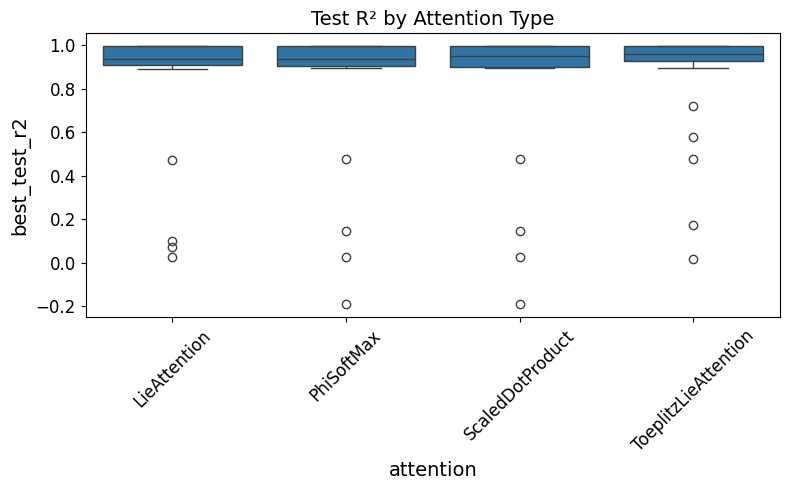

In [15]:
# Example: Compare test R² across attention types
if len(manifest) > 0 and 'attention' in manifest.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    if manifest['best_test_r2'].notna().any():
        sns.boxplot(data=manifest, x='attention', y='best_test_r2', ax=ax)
        ax.set_title('Test R² by Attention Type')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No test R² data available yet.")

---
# 4. Notes & TODO

## Open Questions
1) Why different splits of the same dataset lead to very different learning dynamics? Is there a metric we can use to determine when learning from a particular dataset is "hard"?
2) How dependent from the initial condition (seed) the solution is?
3) Why Toeplitz attention and Lie gated behave differently?
4) In SVFA can the value projection somehow make the alignment learning unnecessary? Example: say I have an edge with a very weak weight. Can the model learn a strong alignment if the value learns to damp it down?
5) Why the noise-aware performed very well with scm6 and not so well with scm7?
&) Why the SA DAG learned in noise_aware_Toeplitz_SM_scm1/2/3 saturates at 0.84?

## Action Plan

1) The first priority is to identify an architecture that provides consistent hypothesis for a given dataset, i.e., it learns the same DAG structure for different cross-validation fold. STATUS: working on it
2) The second step is to make sure we converge to the same solution from different initialization, here double-ML could help as we learn a representation that doesn't depend on nuisance parameters


## Next Experiments to Run
- [ ] Experiment idea 1
- [ ] Experiment idea 2

## Conclusions
- DAG parametrization is for structural learning and therefore useless when using SVF Embeddings/Attention